### Data Preprocessing

In [1]:
import pandas as pd

SDI = ['AGE_DIV','RACE_DIV','EDU_DIV','INC_DIV']
SVI = ['EPL_POV150','EPL_UNEMP','EPL_HBURD','EPL_NOHSDP','EPL_UNINSUR',
       'EPL_AGE65','EPL_AGE17','EPL_DISABL','EPL_SNGPNT','EPL_LIMENG',
       'EPL_MINRTY',
       'EPL_MUNIT','EPL_MOBILE','EPL_CROWD','EPL_NOVEH','EPL_GROUPQ']

df = pd.read_csv('SVI_SDI_RI_Dataset_v2.csv')
df = df[['Age','Race','Education','Income'] + SVI + ['pre_disaster','short_term','long_term']]
df.columns = SDI + SVI + ['PRE_EFFECT','SHORT_IMPACT','LONG_IMPACT']

dic = {0:1, 1:2, 2:0}
df['LONG_IMPACT'] = df['LONG_IMPACT'].apply(lambda x: dic[x])

print(df['PRE_EFFECT'].value_counts())
print(df['LONG_IMPACT'].value_counts())

PRE_EFFECT
0    1208
1     513
Name: count, dtype: int64
LONG_IMPACT
0    1245
2     346
1     130
Name: count, dtype: int64


### Distribution of Features & Targets

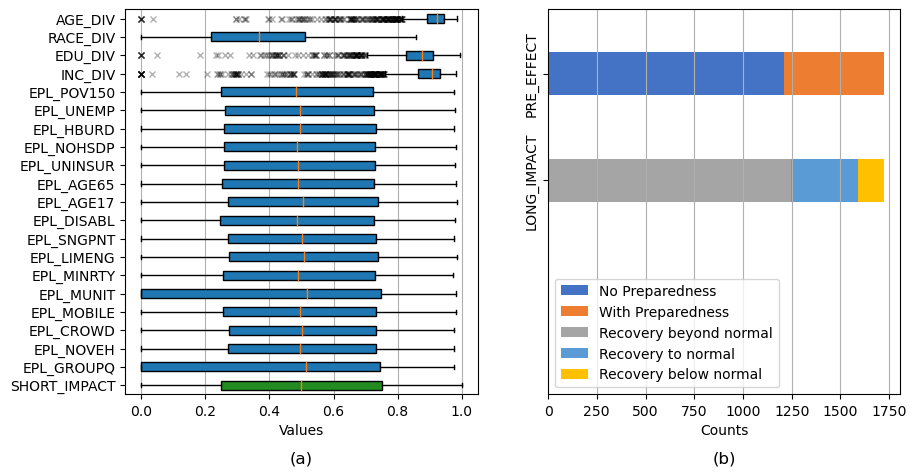

In [2]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(10, 5))

bp = axes[0].boxplot(df[['SHORT_IMPACT'] + SVI[::-1] + SDI[::-1]], vert=False, patch_artist=True)
bp['boxes'][0].set_facecolor('forestgreen')
for flier in bp['fliers']:
    flier.set(marker ='x', markersize=4, alpha=0.3)
axes[0].set_xlabel('Values')
axes[0].xaxis.grid(True)
axes[0].set_yticklabels(['SHORT_IMPACT'] + SVI[::-1] + SDI[::-1])
axes[0].set_title('(a)', y=-0.2)

y = [1.0, 0.75]
x1 = list(df['PRE_EFFECT'].value_counts())
x2 = list(df['LONG_IMPACT'].value_counts())
axes[1].barh(y[0], x1[0], height=0.1, label='No Preparedness', color=(68/255,114/255,196/255))
axes[1].barh(y[0], x1[1], left=x1[0], height=0.1, label='With Preparedness', color=(237/255,125/255,49/255))
axes[1].barh(y[1], x2[0], height=0.1, label='Recovery beyond normal', color=(165/255,165/255,165/255))
axes[1].barh(y[1], x2[1], left=x2[0], height=0.1, label='Recovery to normal', color=(91/255,155/255,213/255))
axes[1].barh(y[1], x2[2], left=x2[0]+x2[1], height=0.1, label='Recovery below normal', color=(255/255,192/255,0/255))
axes[1].set_xlabel('Counts')
axes[1].xaxis.grid(True)
axes[1].set_ylim(0.25, 1.15)
axes[1].set_yticks(y)
axes[1].set_yticklabels(['PRE_EFFECT','LONG_IMPACT'], rotation=90, va='center')
axes[1].legend(loc='lower left')
axes[1].set_title('(b)', y=-0.2)

#plt.savefig('Variables_Distribution.svg', dpi=600, bbox_inches='tight')
plt.show()

### Correlation Matrix

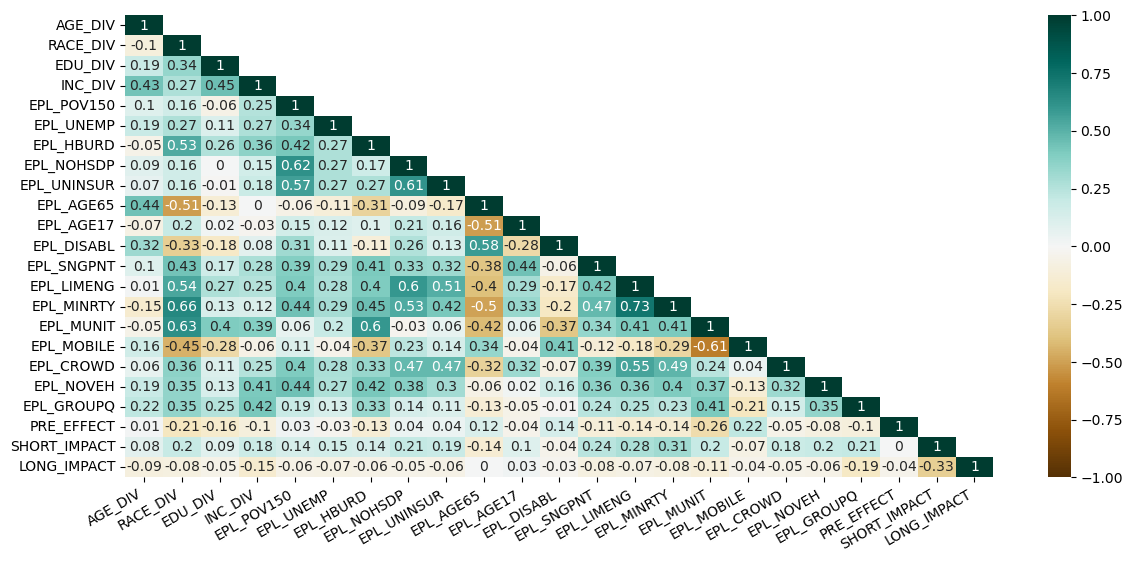

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = df.corr('spearman').round(2)

plt.figure(figsize=(14, 6))
heatmap = sns.heatmap(data, vmin=-1, vmax=1, cmap='BrBG', annot=True, mask=np.triu(np.ones_like(data), 1))
plt.xticks(rotation=30, ha='right')

#plt.savefig('Correlation_Matrix.svg', dpi=600, bbox_inches='tight')
plt.show()

### Partial Dependence Plots (PDP)

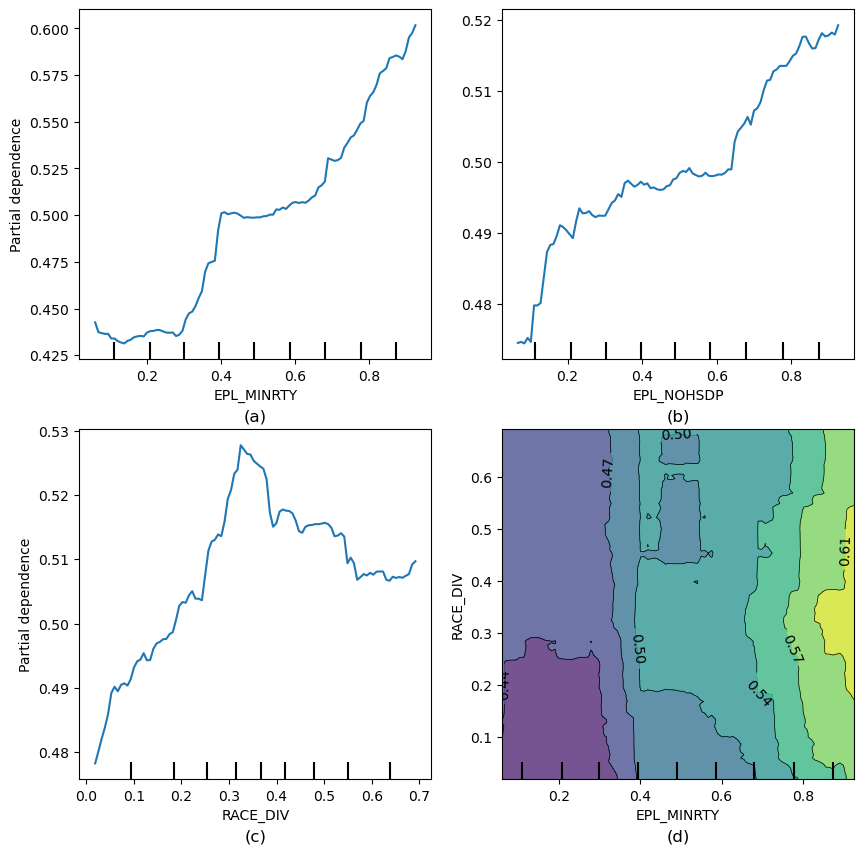

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

X = df[SDI + SVI].values
y = df['SHORT_IMPACT'].values

rf = RandomForestRegressor(n_estimators=120, max_depth=19, max_features=6, random_state=100) #Optimized parameters
rf.fit(X, y)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
PartialDependenceDisplay.from_estimator(rf, X, [14], feature_names=SDI+SVI, ax=axes[0,0])
axes[0,0].set_title('(a)', y=-0.2)
PartialDependenceDisplay.from_estimator(rf, X, [7], feature_names=SDI+SVI, ax=axes[0,1])
axes[0,1].set_title('(b)', y=-0.2)
plt.ylabel('')
PartialDependenceDisplay.from_estimator(rf, X, [1], feature_names=SDI+SVI, ax=axes[1,0])
axes[1,0].set_title('(c)', y=-0.2)
PartialDependenceDisplay.from_estimator(rf, X, [(14,1)], feature_names=SDI+SVI, ax=axes[1,1])
axes[1,1].set_title('(d)', y=-0.2)

#plt.savefig('SHORT_IMPACT_PDP.svg', dpi=600, bbox_inches='tight')
plt.show()

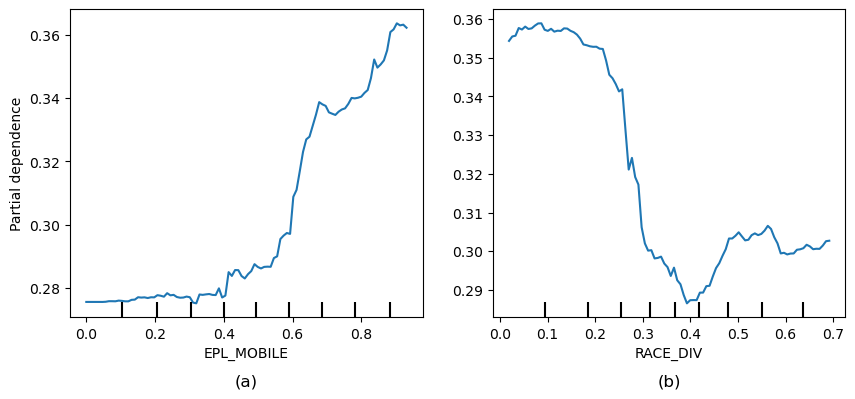

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

X = df[SDI + SVI].values
y = df['PRE_EFFECT'].values

rf = RandomForestClassifier(n_estimators=190, max_depth=10, max_features=4, random_state=100) #Optimized parameters
rf.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
PartialDependenceDisplay.from_estimator(rf, X, [16], feature_names=SDI+SVI, ax=axes[0])
axes[0].set_title('(a)', y=-0.25)
PartialDependenceDisplay.from_estimator(rf, X, [1], feature_names=SDI+SVI, ax=axes[1])
axes[1].set_title('(b)', y=-0.25)
plt.ylabel('')

#plt.savefig('PRE_EFFECT_PDP.svg', dpi=600, bbox_inches='tight')
plt.show()

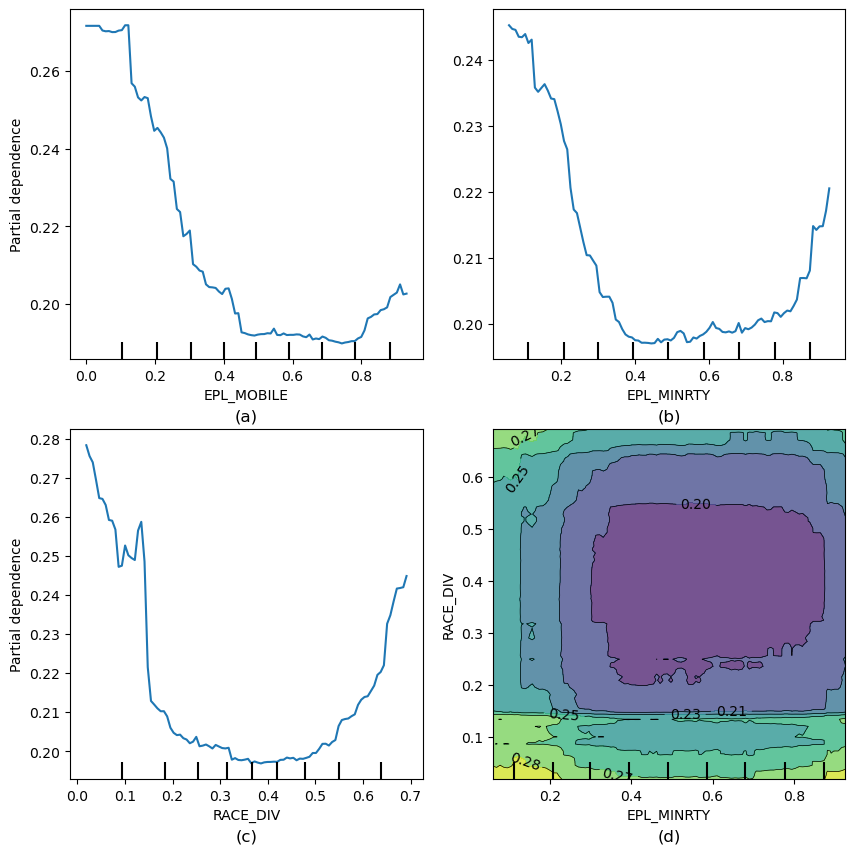

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

X = df[SDI + SVI].values
y = df['LONG_IMPACT'].values

rf = RandomForestClassifier(n_estimators=180, max_depth=20, max_features=4, random_state=100) #Optimized parameters
rf.fit(X, y)

target = 2
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
PartialDependenceDisplay.from_estimator(rf, X, [16], feature_names=SDI+SVI, target=target, ax=axes[0,0])
axes[0,0].set_title('(a)', y=-0.2)
PartialDependenceDisplay.from_estimator(rf, X, [14], feature_names=SDI+SVI, target=target, ax=axes[0,1])
axes[0,1].set_title('(b)', y=-0.2)
plt.ylabel('')
PartialDependenceDisplay.from_estimator(rf, X, [1], feature_names=SDI+SVI, target=target, ax=axes[1,0])
axes[1,0].set_title('(c)', y=-0.2)
PartialDependenceDisplay.from_estimator(rf, X, [(14,1)], feature_names=SDI+SVI, target=target, ax=axes[1,1])
axes[1,1].set_title('(d)', y=-0.2)

#plt.savefig('LONG_IMPACT_PDP_1.svg', dpi=600, bbox_inches='tight')
plt.show()

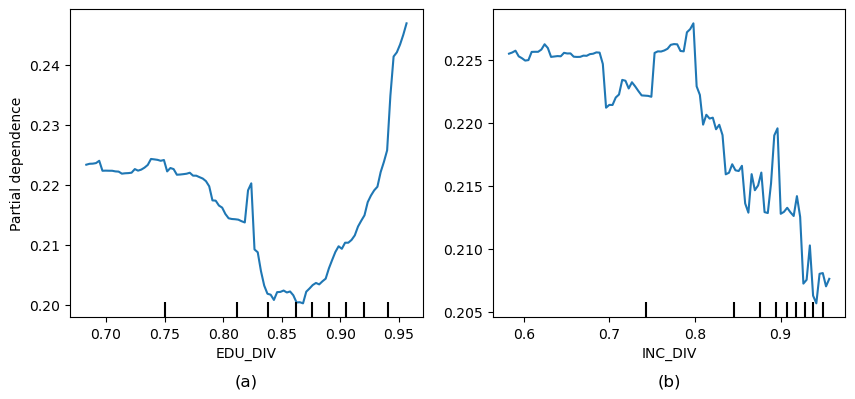

In [7]:
target = 2
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
PartialDependenceDisplay.from_estimator(rf, X, [2], feature_names=SDI+SVI, target=target, ax=axes[0])
axes[0].set_title('(a)', y=-0.25)
PartialDependenceDisplay.from_estimator(rf, X, [3], feature_names=SDI+SVI, target=target, ax=axes[1])
axes[1].set_title('(b)', y=-0.25)
plt.ylabel('')

#plt.savefig('LONG_IMPACT_PDP_2.svg', dpi=600, bbox_inches='tight')
plt.show()